# 02 — Discount models

Fit all six discount functions to synthetic effort data and rank them via AIC/BIC, mimicking Bialaszek et al. (2017)'s functional-form comparison. We'll show that:
1. Each function recovers its own parameters under noise.
2. AIC correctly identifies the source function in clean cases.
3. The functional-form differences are visible across the 10–85% capability range — the same range the Phase 4 experiment will probe.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from edu.models.discounting import (
    Hyperbolic, Exponential, Parabolic, Power, Sigmoidal, Hyperboloid,
    fit_discount, compare_models,
)

rng = np.random.default_rng(2025)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# Match the experimental design: 10, 25, 40, 55, 70, 85% of capability.
EFFORT = np.array([0.10, 0.25, 0.40, 0.55, 0.70, 0.85])
EFFORT_DENSE = np.linspace(0.0, 1.0, 200)

## Visualise all six functional forms

Each panel shows one form across `E ∈ [0, 1]` with parameters chosen so the curves cross roughly at `SV = A/2` near the middle of the effort range. The key visual contrast is between the convex (Hyperbolic/Exponential) and concave (Parabolic/Power) families — the heart of the functional-form debate the unified model addresses.

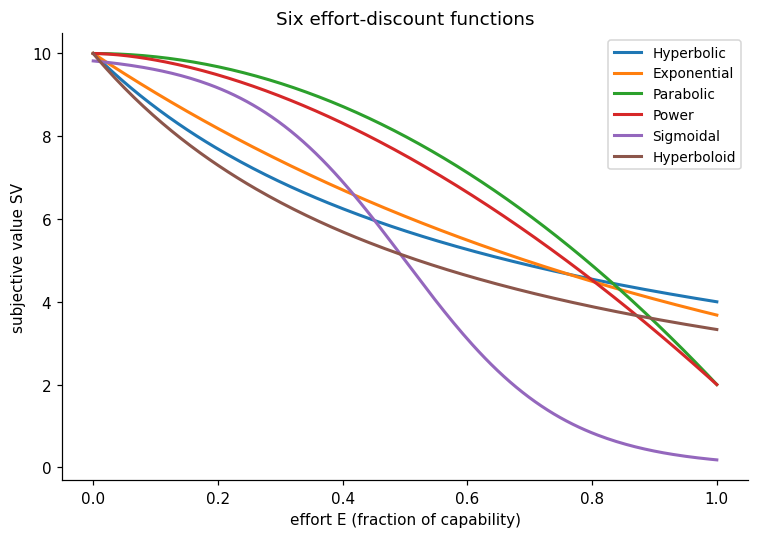

In [2]:
models_with_truth = [
    (Hyperbolic(), {"A": 10.0, "l": 1.5}),
    (Exponential(), {"A": 10.0, "l": 1.0}),
    (Parabolic(), {"A": 10.0, "l": 8.0}),
    (Power(), {"A": 10.0, "l": 8.0, "s": 1.7}),
    (Sigmoidal(), {"A": 10.0, "s": 8.0, "E0": 0.5}),
    (Hyperboloid(), {"A": 10.0, "l": 1.5, "s": 1.2}),
]

fig, ax = plt.subplots(figsize=(7, 5))
for m, p in models_with_truth:
    sv = m.value(p, EFFORT_DENSE)
    ax.plot(EFFORT_DENSE, sv, label=type(m).__name__, lw=2)
ax.set_xlabel("effort E (fraction of capability)")
ax.set_ylabel("subjective value SV")
ax.set_title("Six effort-discount functions")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout(); plt.show()

## Round-trip parameter recovery

For each form, simulate noisy data at the experimental effort grid, fit the same form back, and report relative bias on each parameter. This is a sanity check before the full Phase 3 simulation suite.

In [3]:
noise_sigma = 0.3  # on A=10 scale; ~3% relative noise
print(f"{'model':<12} {'param':<5} {'true':>8} {'fit':>8} {'rel.err':>8}")
print("-" * 50)
for m, p in models_with_truth:
    sv = m.value(p, EFFORT) + rng.normal(0, noise_sigma, size=EFFORT.shape)
    fit = fit_discount(m, EFFORT, sv)
    for name in m.param_names:
        rel = (fit.params[name] - p[name]) / p[name]
        print(f"{type(m).__name__:<12} {name:<5} {p[name]:>8.3f} {fit.params[name]:>8.3f} {rel:>+7.2%}")

model        param     true      fit  rel.err
--------------------------------------------------
Hyperbolic   A       10.000    9.380  -6.20%
Hyperbolic   l        1.500    1.422  -5.18%
Exponential  A       10.000    9.819  -1.81%
Exponential  l        1.000    0.937  -6.29%
Parabolic    A       10.000    9.819  -1.81%
Parabolic    l        8.000    7.150 -10.63%
Power        A       10.000   10.121  +1.21%
Power        l        8.000    7.999  -0.01%
Power        s        1.700    1.502 -11.62%
Sigmoidal    A       10.000   10.442  +4.42%
Sigmoidal    s        8.000    7.361  -7.99%
Sigmoidal    E0       0.500    0.495  -1.06%
Hyperboloid  A       10.000    9.779  -2.21%
Hyperboloid  l        1.500    1.171 -21.96%
Hyperboloid  s        1.200    1.373 +14.38%


## Model comparison: does AIC pick the right form?

For each truth model, fit all six candidates to the noisy data and rank by AIC. With six effort points and small noise the truth model should win, but the margin between functionally similar candidates (e.g. hyperbolic vs hyperboloid with `s=1`) can be small. The Phase 3 simulation suite will run this systematically across sample sizes.

In [4]:
candidates = [Hyperbolic(), Exponential(), Parabolic(), Power(), Sigmoidal(), Hyperboloid()]
for source, true_p in models_with_truth:
    sv = source.value(true_p, EFFORT) + rng.normal(0, noise_sigma, size=EFFORT.shape)
    results = compare_models(candidates, EFFORT, sv)
    ranked = sorted(results.items(), key=lambda kv: kv[1].aic)
    print(f"\nTrue source = {type(source).__name__}")
    for name, r in ranked:
        marker = "  ← truth" if name == type(source).__name__ else ""
        print(f"  {name:<12} AIC={r.aic:>7.2f}  R²={r.r_squared:.3f}{marker}")


True source = Hyperbolic
  Hyperboloid  AIC=   1.06  R²=0.989
  Hyperbolic   AIC=   2.12  R²=0.981  ← truth
  Power        AIC=   2.49  R²=0.986
  Exponential  AIC=   7.84  R²=0.951
  Sigmoidal    AIC=  12.24  R²=0.927
  Parabolic    AIC=  17.95  R²=0.735

True source = Exponential
  Exponential  AIC=   9.87  R²=0.956  ← truth
  Hyperbolic   AIC=  10.81  R²=0.949
  Power        AIC=  11.19  R²=0.961
  Hyperboloid  AIC=  11.85  R²=0.956
  Sigmoidal    AIC=  12.50  R²=0.951
  Parabolic    AIC=  17.36  R²=0.848

True source = Parabolic
  Parabolic    AIC=   5.83  R²=0.981  ← truth
  Sigmoidal    AIC=   7.56  R²=0.982
  Power        AIC=   7.81  R²=0.981
  Exponential  AIC=  16.77  R²=0.880
  Hyperbolic   AIC=  19.01  R²=0.826
  Hyperboloid  AIC=  19.03  R²=0.875

True source = Power
  Power        AIC= -21.75  R²=1.000  ← truth
  Sigmoidal    AIC=  -9.63  R²=0.999
  Exponential  AIC=   8.69  R²=0.974
  Parabolic    AIC=  10.43  R²=0.965
  Hyperboloid  AIC=  11.50  R²=0.970
  Hyperbolic  


True source = Hyperboloid
  Hyperbolic   AIC=   2.34  R²=0.985
  Power        AIC=   3.36  R²=0.987
  Hyperboloid  AIC=   4.33  R²=0.985  ← truth
  Exponential  AIC=   6.19  R²=0.972
  Sigmoidal    AIC=  10.89  R²=0.956
  Parabolic    AIC=  18.20  R²=0.790


## Visualise the fits

The clearest illustration of why the functional-form debate exists: convex (Hyperbolic, Exponential) and concave (Parabolic, Power) families produce visibly different curves at high effort. Phase 2's unified model will show how these are limiting cases of a single capability-bounded process.

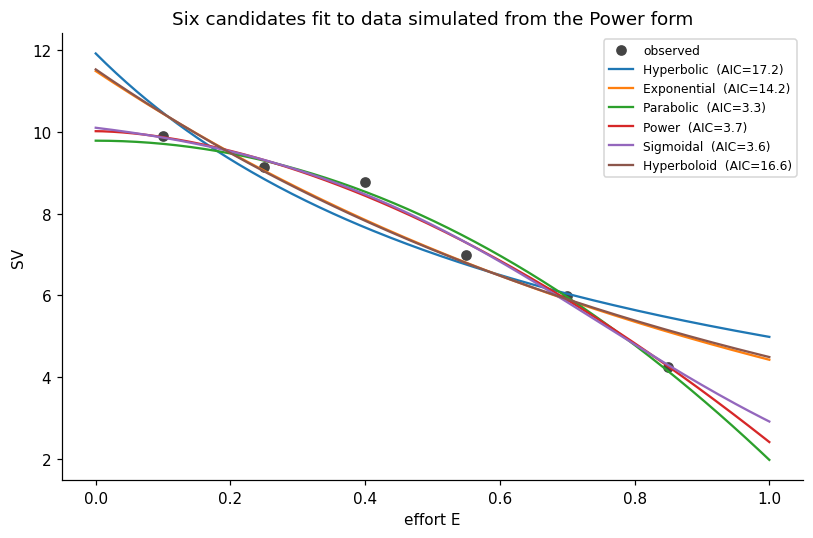

In [5]:
source = Power()
true_p = {"A": 10.0, "l": 8.0, "s": 1.7}
sv_obs = source.value(true_p, EFFORT) + rng.normal(0, noise_sigma, size=EFFORT.shape)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(EFFORT, sv_obs, "o", color="#444", label="observed")
for m in candidates:
    fit = fit_discount(m, EFFORT, sv_obs)
    ax.plot(EFFORT_DENSE, m.value(fit.params, EFFORT_DENSE),
            label=f"{type(m).__name__}  (AIC={fit.aic:.1f})", lw=1.5)
ax.set_xlabel("effort E"); ax.set_ylabel("SV")
ax.set_title("Six candidates fit to data simulated from the Power form")
ax.legend(loc="best", fontsize=8)
fig.tight_layout(); plt.show()